# 1. Data Exploration of the Cora Dataset

In this notebook, we load the Cora dataset, explore its structure, visualize node degrees, check class distribution, and plot a small subgraph to understand the citation network.

In [1]:
import sys
sys.path.append('../src')
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from dataset import load_data

np.random.seed(42)
torch.manual_seed(42)

In [2]:
# Load the dataset (downloads automatically if not present)
adj, features, labels, idx_train, idx_val, idx_test = load_data(data_dir='../data/cora')

print('-' * 40)
print(f'Feature matrix X shape  : {features.shape}')  # (2708, 1433)
print(f'Adjacency matrix A shape: {adj.shape}')        # (2708, 2708)
print(f'Labels y shape          : {labels.shape}')     # (2708,)
print(f'Number of classes       : {labels.max().item() + 1}')
print(f'Train nodes             : {idx_train.shape[0]}')
print(f'Val nodes               : {idx_val.shape[0]}')
print(f'Test nodes              : {idx_test.shape[0]}')
print('-' * 40)

Loading cora dataset...
----------------------------------------
Feature matrix X shape  : torch.Size([2708, 1433])
Adjacency matrix A shape: torch.Size([2708, 2708])
Labels y shape          : torch.Size([2708])
Number of classes       : 7
Train nodes             : 140
Val nodes               : 300
Test nodes              : 1000
----------------------------------------


/home/roshinit-a/Documents/internships/Niser 2026/GNN/gnn-from-scratch/notebooks/../src/dataset.py:126: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(indices, values, shape).coalesce()


## Degree Distribution

Here we compute the degree of each node. Since our adjacency matrix includes self-loops (A + I), we subtract 1 to get the true edge degrees.

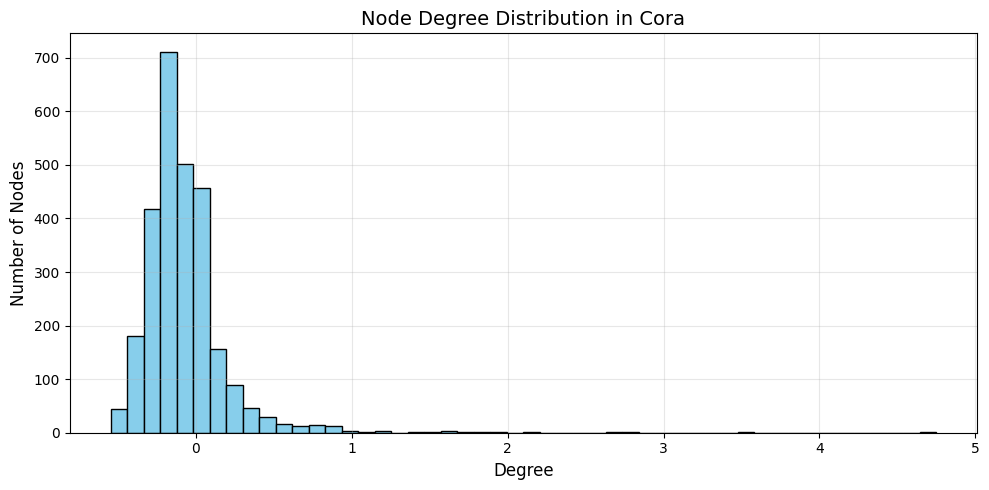

Average Degree: -0.07 | Max Degree: 4


In [3]:
# Convert sparse tensor to dense and compute row sums (degrees)
# Subtract 1 to remove effect of self-loop added during normalization
degrees = adj.to_dense().sum(dim=1).numpy() - 1.0

plt.figure(figsize=(10, 5))
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')
plt.title('Node Degree Distribution in Cora', fontsize=14)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/degree_distribution.png', dpi=150)
plt.show()
print(f'Average Degree: {degrees.mean():.2f} | Max Degree: {int(degrees.max())}')

## Class Distribution

Cora has 7 academic topics as class labels. Let's see how balanced they are.

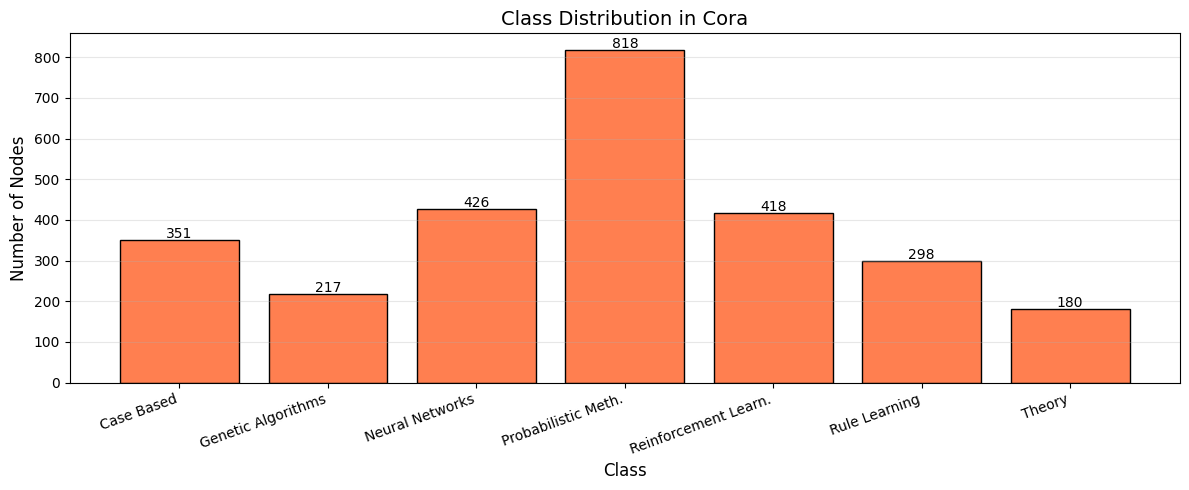

In [4]:
classes, counts = np.unique(labels.numpy(), return_counts=True)
class_names = ['Case Based', 'Genetic Algorithms', 'Neural Networks',
               'Probabilistic Meth.', 'Reinforcement Learn.', 'Rule Learning', 'Theory']

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, color='coral', edgecolor='black')
plt.title('Class Distribution in Cora', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.xticks(rotation=20, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5, str(count), ha='center')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## Subgraph Visualization

We extract a 50-node subgraph centered on the highest-degree node to visually inspect the citation structure.

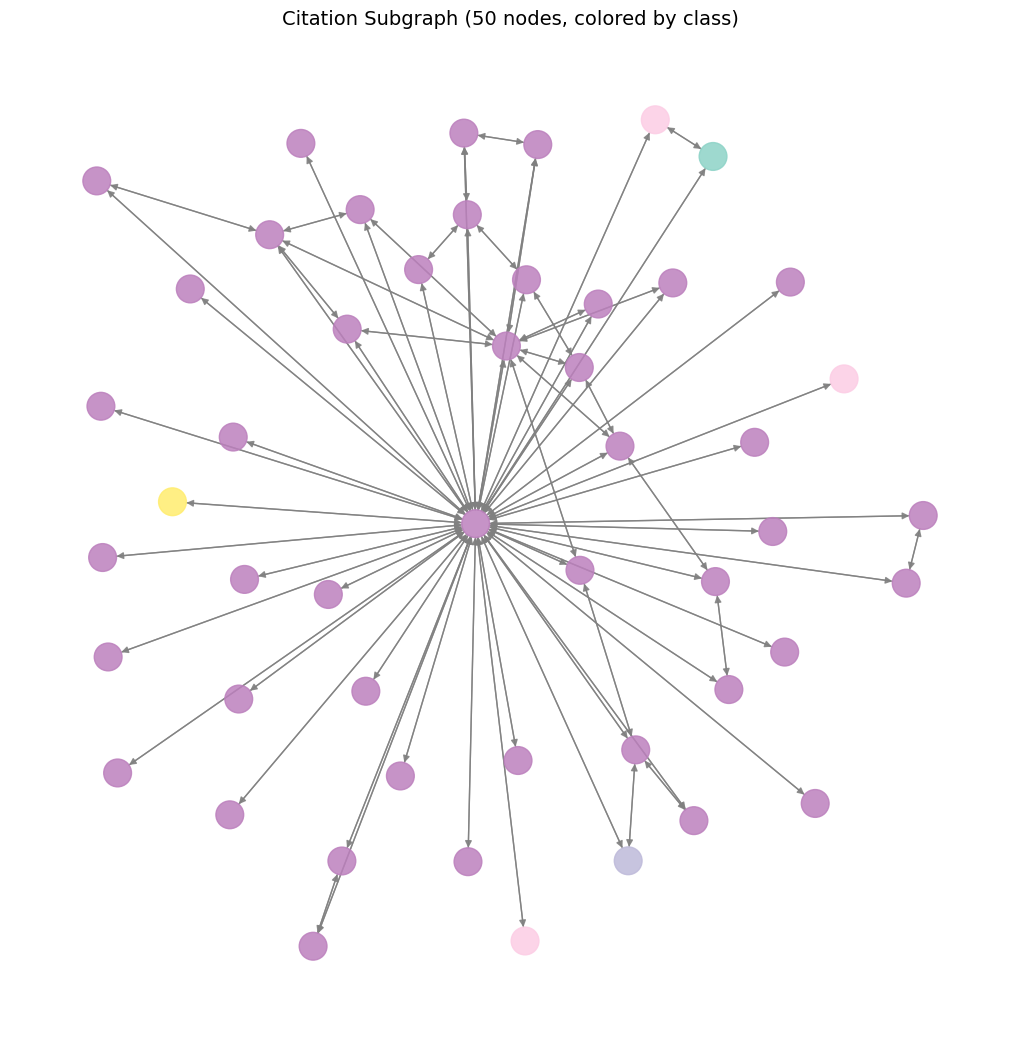

In [5]:
# Convert adjacency to dense numpy for NetworkX
A_dense = adj.to_dense().numpy()
np.fill_diagonal(A_dense, 0)  # Remove self-loops for cleaner visualization

# Build a NetworkX directed graph
G = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)

# Start from the highest-degree node and expand BFS to get 50 connected nodes
start_node = int(np.argmax(degrees))
subgraph_nodes = list(nx.single_source_shortest_path_length(G, start_node, cutoff=2).keys())[:50]
subgraph = G.subgraph(subgraph_nodes)

plt.figure(figsize=(10, 10))
node_colors = [labels[n].item() for n in subgraph.nodes()]
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph, pos,
        node_color=node_colors, cmap=plt.cm.Set3,
        node_size=400, with_labels=False,
        edge_color='gray', arrows=True, alpha=0.85)
plt.title('Citation Subgraph (50 nodes, colored by class)', fontsize=14)
plt.savefig('../results/subgraph.png', dpi=150)
plt.show()